In [1]:
import pandas as pd 
import pulp

In [2]:
file = '/Users/an-chilu/Desktop/Career/Past Projects/Electricity Plant Power Optimization/Prices.xlsx'
xls = pd.ExcelFile(file)
print(xls.sheet_names)

['PRICE_ELECTRIC', 'PRICE_GAS', 'PRICE_CO2']


In [3]:
electric = pd.read_excel(file, sheet_name='PRICE_ELECTRIC')
gas = pd.read_excel(file, sheet_name='PRICE_GAS')
co2 = pd.read_excel(file, sheet_name='PRICE_CO2')

In [4]:
gas

,OPERATING_DATE,PG&E Citygate ($/MMBtu)
0,2022-03-21,7.05
1,2022-03-22,6.99
2,2022-03-23,6.80
3,2022-03-24,7.04
4,2022-03-25,7.01
5,2022-03-26,7.41
6,2022-03-27,7.41


In [5]:
# Example expected columns:
# elec: ['OPERATING_DATE', 'HOUR_ENDING', 'PRICE_ELECTRIC']
# gas:  ['OPERATING_DATE', 'PRICE_GAS']

# Merge daily gas price into each hour
df = electric.merge(gas, on="OPERATING_DATE", how="left")

T = list(range(len(df)))          # 0..167
C = [1, 2, 3, 4, 5]               # configurations

# =========================
# 2. PARAMETERS
# =========================
# You should replace these with YOUR Task 2a values
P_elec = {t: df.loc[t, "NP15 ($/MWh)"] for t in T}
P_gas  = {t: df.loc[t, "PG&E Citygate ($/MMBtu)"] for t in T}

# Configuration min/max MW
Pmin = {
    1: 0,    # off
    2: 57,   # CT1
    3: 114,  # CT1 + CT2, if you model as 2 simple cycles
    4: 150,  # 1x1
    5: 312   # 2x1
}
Pmax = {
    1: 0,
    2: 190,
    3: 380,
    4: 340,
    5: 610
}

# Minimum load cost ($/hr) from Task 2a
ML_dollar = {
    1: 0,
    2: 57 * 5.0,
    3: 114 * 5.0,
    4: 150 * 2.5,
    5: 312 * 2.0
}

# Minimum load fuel (MMBtu/hr) from Task 2a
ML_fuel = {
    1: 0,
    2: 57 * 12.591,
    3: 114 * 12.591,   # only if you choose this assumption
    4: 150 * 7.695,
    5: 312 * 7.121
}

# Startup cost ($/start)
SU_dollar = {
    1: 0,
    2: 7250,
    3: 14500,   # if configuration 3 = two CT starts
    4: 16500,
    5: 16500 + 7250
}

# Startup fuel (MMBtu/start)
SU_fuel = {
    1: 0,
    2: 220,
    3: 440,
    4: 850,
    5: 850 + 220
}

# Approximate incremental variable cost above minimum load ($/MWh)
# This is a simplification. You can refine with piecewise linear blocks later.
inc_cost = {
    1: 0,
    2: 12.591 * 0 + 5.0,   # placeholder
    3: 12.591 * 0 + 5.0,
    4: 7.695 * 0 + 2.5,
    5: 7.121 * 0 + 2.0
}

# Better: compute hourly incremental cost from gas price
# inc_cost[c,t] = heat_rate * gas_price + vom
# Here I use one heat rate per config as a simple approximation:
HR = {
    1: 0,
    2: 12.591,
    3: 12.591,
    4: 7.695,
    5: 7.121
}
VOM = {
    1: 0,
    2: 5.0,
    3: 5.0,
    4: 2.5,
    5: 2.0
}

# =========================
# 3. MODEL
# =========================
model = pulp.LpProblem("CCGT_CAISO_MSG", pulp.LpMaximize)

# Binary: configuration active
y = pulp.LpVariable.dicts("y", ((c, t) for c in C for t in T), cat="Binary")

# Binary: startup
s = pulp.LpVariable.dicts("s", ((c, t) for c in C for t in T), cat="Binary")

# MW generated in each configuration
g = pulp.LpVariable.dicts("g", ((c, t) for c in C for t in T), lowBound=0)

# Total generation
G = pulp.LpVariable.dicts("G", (t for t in T), lowBound=0)

# =========================
# 4. OBJECTIVE
# =========================
model += pulp.lpSum(
    P_elec[t] * G[t]
    - pulp.lpSum(ML_dollar[c] * y[(c, t)] for c in C)
    - pulp.lpSum(P_gas[t] * ML_fuel[c] * y[(c, t)] for c in C)
    - pulp.lpSum(SU_dollar[c] * s[(c, t)] for c in C)
    - pulp.lpSum(P_gas[t] * SU_fuel[c] * s[(c, t)] for c in C)
    - pulp.lpSum((HR[c] * P_gas[t] + VOM[c]) * (g[(c, t)] - Pmin[c] * y[(c, t)]) for c in C if c != 1)
    for t in T
)

# =========================
# 5. CONSTRAINTS
# =========================

# (a) Exactly one configuration each hour
for t in T:
    model += pulp.lpSum(y[(c, t)] for c in C) == 1

# (b) Generation bounds by configuration
for t in T:
    for c in C:
        model += g[(c, t)] >= Pmin[c] * y[(c, t)]
        model += g[(c, t)] <= Pmax[c] * y[(c, t)]

# (c) Total generation
for t in T:
    model += G[t] == pulp.lpSum(g[(c, t)] for c in C)

# (d) Startup logic
# Assume initial configuration is OFF
for c in C:
    if c == 1:
        model += s[(c, 0)] == 0
    else:
        model += s[(c, 0)] >= y[(c, 0)]
        model += s[(c, 0)] <= y[(c, 0)]

for t in T[1:]:
    for c in C:
        if c == 1:
            model += s[(c, t)] == 0
        else:
            model += s[(c, t)] >= y[(c, t)] + y[(1, t-1)] - 1
            model += s[(c, t)] <= y[(c, t)]
            model += s[(c, t)] <= y[(1, t-1)]

# =========================
# 6. SOLVE
# =========================
solver = pulp.PULP_CBC_CMD(msg=True)
model.solve(solver)

print("Status:", pulp.LpStatus[model.status])
print("Objective value:", pulp.value(model.objective))

# =========================
# 7. EXTRACT RESULTS
# =========================
results = []
for t in T:
    active_config = None
    for c in C:
        if pulp.value(y[(c, t)]) > 0.5:
            active_config = c
            break

    results.append({
        "OPERATING_DATE": df.loc[t, "OPERATING_DATE"],
        "HOUR_ENDING": df.loc[t, "HOUR_ENDING"],
        "PRICE_ELECTRIC": df.loc[t, "NP15 ($/MWh)"],
        "PRICE_GAS": df.loc[t, "PG&E Citygate ($/MMBtu)"],
        "CONFIGURATION_ACTIVE": active_config,
        "MW_GENERATION": pulp.value(G[t])
    })

out = pd.DataFrame(results)
out.to_csv("CCGT_CAISO.csv", index=False)

print(out.head(12))

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/an-chilu/Desktop/Career/Past Projects/Electricity Plant Power Optimization/venv/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/2s/pf3bmr2d1hdbcgx17_5vywdr0000gn/T/c7340a31014f4b6dbfab111373a5e26a-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/2s/pf3bmr2d1hdbcgx17_5vywdr0000gn/T/c7340a31014f4b6dbfab111373a5e26a-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 4201 COLUMNS
At line 19478 RHS
At line 23675 BOUNDS
At line 25356 ENDATA
Problem MODEL has 4196 rows, 2688 columns and 9732 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 675483 - 0.01 seconds
Cgl0002I 168 variables fixed
Cgl0003I 0 fixed, 0 tightened bounds, 514 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 653 strengthened rows, 0 

In [ ]:
# results = []
# for t in T:
#     active_config = None
#     for c in C:
#         if pulp.value(y[(c, t)]) > 0.5:
#             active_config = c
#             break

#     results.append({
#         "OPERATING_DATE": df.loc[t, "OPERATING_DATE"],
#         "HOUR_ENDING": df.loc[t, "HOUR_ENDING"],
#         "PRICE_ELECTRIC": df.loc[t, "NP15 ($/MWh)"],
#         "PRICE_GAS": df.loc[t, "PG&E Citygate ($/MMBtu)"],
#         "CONFIGURATION_ACTIVE": active_config,
#         "MW_GENERATION": pulp.value(G[t])
#     })

# out = pd.DataFrame(results)

# # optional: round generation
# out["MW_GENERATION"] = out["MW_GENERATION"].round(2)

# # save as CSV
# out.to_csv("CCGT_CAISO.csv", index=False)

In [8]:
print(out.head(12).to_string(index=False))

OPERATING_DATE  HOUR_ENDING  PRICE_ELECTRIC  PRICE_GAS  CONFIGURATION_ACTIVE  MW_GENERATION
    2022-03-21            1           45.04       7.05                     1            0.0
    2022-03-21            2           43.63       7.05                     1            0.0
    2022-03-21            3           43.43       7.05                     1            0.0
    2022-03-21            4           43.42       7.05                     1            0.0
    2022-03-21            5           46.30       7.05                     2           57.0
    2022-03-21            6           55.50       7.05                     5          610.0
    2022-03-21            7           76.70       7.05                     5          610.0
    2022-03-21            8           77.29       7.05                     5          610.0
    2022-03-21            9           51.19       7.05                     1            0.0
    2022-03-21           10           46.89       7.05                     1    

# Plots

## MW vs. hour

In [12]:
import matplotlib.pyplot as plt
CCGT = pd.read_csv('/Users/an-chilu/Desktop/Career/Past Projects/Electricity Plant Power Optimization/CCGT_CAISO.csv')

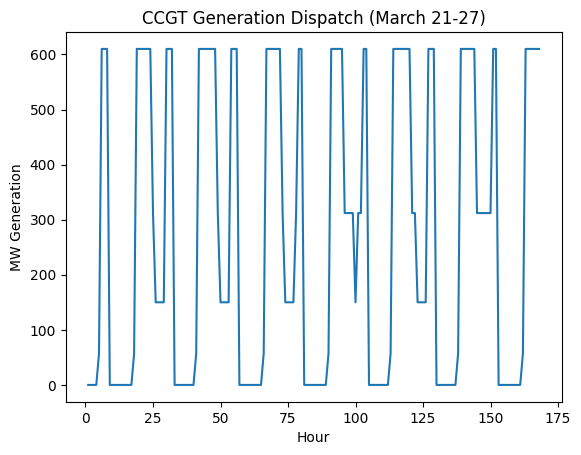

In [28]:
plt.plot(range(1, 169), CCGT['MW_GENERATION'])
plt.xlabel('Hour')
plt.ylabel('MW Generation')
plt.title('CCGT Generation Dispatch (March 21-27)');

## Configuration Mode vs. Time

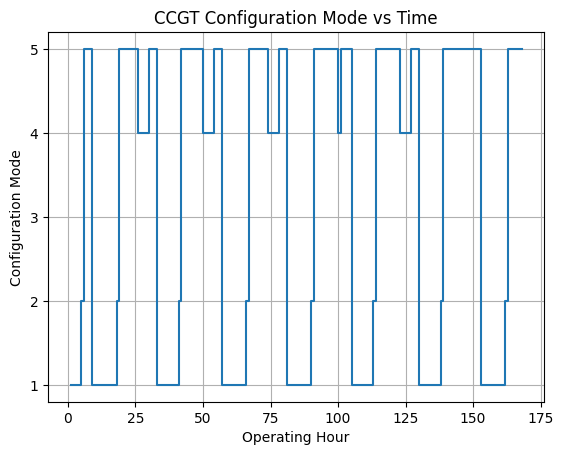

In [21]:
plt.step(range(1,169), CCGT['CONFIGURATION_ACTIVE'], where='post')

plt.xlabel("Operating Hour")
plt.ylabel("Configuration Mode")
plt.title("CCGT Configuration Mode vs Time")

plt.yticks([1,2,3,4,5])
plt.grid(True);

In [29]:
pd.read_csv('/Users/an-chilu/Desktop/Career/Past Projects/Electricity Plant Power Optimization/CCGT_CAISO.csv')

,OPERATING_DATE,HOUR_ENDING,PRICE_ELECTRIC,PRICE_GAS,CONFIGURATION_ACTIVE,MW_GENERATION
0,2022-03-21,1,45.04,7.05,1,0.0
1,2022-03-21,2,43.63,7.05,1,0.0
2,2022-03-21,3,43.43,7.05,1,0.0
3,2022-03-21,4,43.42,7.05,1,0.0
4,2022-03-21,5,46.30,7.05,2,57.0
...,...,...,...,...,...,...
163,2022-03-27,20,94.18,7.41,5,610.0
164,2022-03-27,21,92.23,7.41,5,610.0
165,2022-03-27,22,75.27,7.41,5,610.0
166,2022-03-27,23,65.95,7.41,5,610.0


In [45]:
# Total Revenue ($)
total_revenue = round((CCGT['PRICE_ELECTRIC'] * CCGT['MW_GENERATION']).sum(), 2)
print(f'Total Revenue ($) = {total_revenue}')

# Total Costs ($)
profit = pulp.value(model.objective)
total_costs = total_revenue - profit
print(f'Total Costs ($) = {round(total_costs, 2)}')

# Fuel Costs ($)
fuel_cost = 0

for t in T:
    for c in C:
        fuel_cost += P_gas[t] * ML_fuel[c] * pulp.value(y[(c, t)])
        fuel_cost += P_gas[t] * SU_fuel[c] * pulp.value(s[(c, t)])
        if c != 1:
            fuel_cost += P_gas[t] * HR[c] * (
                pulp.value(g[(c, t)]) - Pmin[c] * pulp.value(y[(c, t)])
            )

print(f'Fuel Costs ($) = {round(fuel_cost, 2)}')

# Gross Margin (in $/kW)
gross_margin = profit / 610000
print(f'Gross Margin (in $/kW) = {round(gross_margin, 2)}')

# Capacity Factor (%)
capacity_factor = CCGT["MW_GENERATION"].sum() / (610 * 168) * 100
print(f'Capacity Factor (%) = {round(capacity_factor, 2)}')

# Number of Starts
number_of_starts = (
    (CCGT["CONFIGURATION_ACTIVE"] != 1) &
    (CCGT["CONFIGURATION_ACTIVE"].shift(1) == 1)
).sum()
print(f'Number of Starts = {number_of_starts}')

Total Revenue ($) = 3095982.18
Total Costs ($) = 2511536.63
Fuel Costs ($) = 2359229.63
Gross Margin (in $/kW) = 0.96
Capacity Factor (%) = 44.72
Number of Starts = 8
